# 01 — Warehouse population

This notebook is the entry point to the SuSSE warehouse — the shared data store every other notebook in the refactor track reads from. Three sections, in order:

1. **The model** — what we're building, in one paragraph.
2. **The warehouse** — what's in it, where the data comes from, and the hard constraint it imposes.
3. **Extending the warehouse** — the three ingest patterns and how to add new stations / regions / sources.

Code cells default to **read-only mode** (`RUN_INGEST=False` near the top) — they query the warehouse and show what *would* happen, but don't call external APIs or write rows. Real mutations live in `warehouse/migrations/`. Library architecture and operational practices are documented separately in [`docs/architecture.md`](../docs/architecture.md).

## 1. The model

The SuSSE bias-correction model takes a satellite GHI estimate (from NASA POWER and/or CAMS) plus atmospheric variables at a specific (lat, lon, date), and predicts the **unbiased GHI** for that point. Satellite estimates have systematic 5–15 % biases over Sub-Saharan Africa; the model learns to correct them.

It's trained on **paired data**: at each of our 28 ground-measurement stations, every day where we have both a ground GHI reading and the matching satellite estimate becomes one training example. Once trained, applying the model to a new (lat, lon, date) requires the same shape of input — a satellite estimate plus atmospheric variables for that point. That's what the warehouse is for.

## 2. The warehouse

Both training and inference need the same data shape — `(satellite GHI estimate, atmospheric features) at (lat, lon, date)` — so we pre-stage everything in one BigQuery dataset (`solar-irradiation-estimation.solar_warehouse`) and read from there. For training that's the 28 ground stations × their date ranges; for inference it's any (lat, lon, date) a downstream caller might ask about.

**The hard constraint:** the model can only score (lat, lon, date) tuples for which the warehouse already holds the satellite estimate and atmospheric variables. Adding a new station to the training corpus, or a new region to inference coverage, requires an ingest run first. Section 3 shows how.

The cells below tour the warehouse as it stands today, then summarise where each table's data comes from.

### Setup

In [25]:
from datetime import date
from pathlib import Path
import logging
import os

import pandas as pd

from susse.warehouse_ops.io import (
    BigQueryClient,
    TableRefs,
    TableSchemas,
    WarehouseConfig,
)
from susse.warehouse_ops.population import (
    BoundingBox,
    CamsSatelliteJob,
    CurationOptions,
    DateRange,
    GridPlan,
    GridSpec,
    GroundFilePlan,
    GroundIngestJob,
    LocationSpec,
    NamedLocationsPlan,
    NasaPowerSatelliteJob,
    Source,
    StandardCsvAdapter,
    VariableCatalog,
    curate_ground,
    populate_dim_variable,
    variables_to_dataframe,
)

logging.basicConfig(level=logging.INFO, format="%(asctime)s | %(levelname)s | %(message)s")

In [26]:
# Master toggle: when False, the notebook reads the warehouse and shows what
# would happen, but never calls a satellite API or writes a row. Flip to True
# only when you actually want to ingest.
RUN_INGEST = False

config = WarehouseConfig()  # defaults to solar-irradiation-estimation / solar_warehouse
tables = TableRefs(config=config)
bq = BigQueryClient(config=config)

print(f"project : {config.project_id}")
print(f"dataset : {config.dataset}")
print(f"RUN_INGEST = {RUN_INGEST}")

project : solar-irradiation-estimation
dataset : solar_warehouse
RUN_INGEST = False


### Live warehouse tour

What's in the warehouse right now, queried directly. Re-running this notebook over time will show the warehouse growing as we run the ingest jobs.

In [52]:
import warnings; warnings.filterwarnings('ignore')
from susse.warehouse_ops.io import BigQueryClient, TableRefs
bq = BigQueryClient(); refs = TableRefs()
df = bq.query(f'''
        SELECT geohash5, variable_id, COUNT(*) AS n_days
        FROM {refs.merra_daily_vars_long}
        GROUP BY geohash5, variable_id
        ORDER BY geohash5, variable_id
    ''')
print(df.to_string(index=False))

geohash5        variable_id  n_days
   str44 aod_550_extinction     416
   str44 aod_550_scattering     434
   str44 precipitable_water     428


In [71]:
# Each table or view in the warehouse, with its size and kind. Joining
# __TABLES__ (which has row_count + size_bytes) to INFORMATION_SCHEMA.TABLES
# (which has table_type) so views are labelled as such — __TABLES__ alone
# reports row_count=0 for views (they're computed on demand, not stored),
# which would otherwise look like the views are empty.
tables_df = bq.query(f"""
SELECT t.table_id,
       ts.table_type,
       t.row_count,3
       ROUND(t.size_bytes / 1024 / 1024, 1) AS size_mb
FROM `{config.project_id}.{config.dataset}.__TABLES__` AS t
LEFT JOIN `{config.project_id}.{config.dataset}.INFORMATION_SCHEMA.TABLES` AS ts
  ON t.table_id = ts.table_name
ORDER BY t.size_bytes DESC, t.table_id
""")
tables_df

,table_id,table_type,row_count,size_mb
0,nasa_daily_vars_long,BASE TABLE,21658619,2133.8
1,cams_daily_vars_long,BASE TABLE,4488930,406.7
2,irradiance_daily,BASE TABLE,1496310,149.6
3,ground_measurements,BASE TABLE,25044,3.3
4,merra_daily_vars_long,BASE TABLE,13601,1.4
5,ground_measurements_raw,BASE TABLE,25044,1.1
6,modis_observations,BASE TABLE,6528,0.7
7,dim_variable,BASE TABLE,48,0.0
8,v_irr_monthly_by_point,VIEW,0,0.0
9,v_irr_weekly_by_point,VIEW,0,0.0


In [28]:
irradiance_summary = bq.query(f"""
SELECT source,
       COUNT(*)                            AS n_rows,
       COUNT(DISTINCT geohash5)            AS n_points,
       MIN(date)                           AS first_date,
       MAX(date)                           AS last_date,
       ROUND(MIN(latitude), 2)             AS min_lat,
       ROUND(MAX(latitude), 2)             AS max_lat,
       ROUND(MIN(longitude), 2)            AS min_lon,
       ROUND(MAX(longitude), 2)            AS max_lon
FROM `{tables.irradiance_daily}`
GROUP BY source
ORDER BY source
""")
irradiance_summary

,source,n_rows,n_points,first_date,last_date,min_lat,max_lat,min_lon,max_lon
0,CAMS,748155,1986,2011-03-08,2024-12-31,-25.05,29.89,-0.11,46.95
1,NASA,748155,1986,2011-03-08,2024-12-31,-25.05,29.89,-0.11,46.95


In [29]:
ground_summary = bq.query(f"""
SELECT location,
       COUNT(*)                AS n_days,
       MIN(date)               AS first_date,
       MAX(date)               AS last_date,
       ROUND(AVG(lat), 4)      AS lat,
       ROUND(AVG(lon), 4)      AS lon,
       ROUND(AVG(ghi_kwh_m2_day), 2) AS ghi_mean_kwh
FROM `{tables.ground_measurements}`
GROUP BY location
ORDER BY n_days DESC
""")
ground_summary

,location,n_days,first_date,last_date,lat,lon,ghi_mean_kwh
0,kenya_location3,1976,2019-05-28,2024-11-25,-0.4700,35.1819,5.89
1,lira,1935,2014-08-27,2023-02-01,2.2952,32.9214,4.43
2,kampala,1798,2011-04-06,2023-01-22,0.3335,32.5686,4.49
3,ghana_location1,1774,2019-09-24,2024-11-25,5.6458,-0.1052,4.69
4,nigeria_location1,1641,2020-04-04,2024-11-25,9.0764,7.4254,4.95
5,kenya_location5,1382,2020-12-22,2024-11-25,-0.2200,35.8600,5.67
6,tororo,1380,2011-03-08,2017-11-22,0.6978,34.1715,5.66
7,ghana_location3,1320,2021-02-25,2024-11-25,-0.2351,5.6322,4.29
8,ghana_location2,1105,2020-01-31,2024-05-02,5.6457,0.0087,4.87
9,kenya_location2,1016,2019-10-08,2024-02-23,0.6100,36.8000,5.92


### Coverage audit

Two quick queries to spot-check the warehouse: per-source variable coverage in the long tables, and training-pair availability per ground station (ground ⨝ `irradiance_daily` on `(date, geohash5)`). The full audit lives in `scripts/audit_warehouse.py`; these cells are the small subset most useful when looking up "is the warehouse ready for X?".

The pair-availability cell is the canary: every station should have `n_nasa_pairs > 0` and `n_cams_pairs > 0` after the 28-station ingest runs.

In [30]:
# Per-source variable coverage in the long tables. After Phase A this
# should show ~30+ NASA POWER variables and 6 CAMS aux variables for
# the Uganda 2024 grid.
coverage_df = bq.query(f"""
SELECT 'NASA' AS source, variable_id, COUNT(*) AS n_rows,
       COUNT(DISTINCT geohash5) AS n_points,
       MIN(date) AS min_date, MAX(date) AS max_date
FROM `{tables.nasa_daily_vars_long}`
GROUP BY variable_id
UNION ALL
SELECT 'CAMS' AS source, variable_id, COUNT(*) AS n_rows,
       COUNT(DISTINCT geohash5) AS n_points,
       MIN(date) AS min_date, MAX(date) AS max_date
FROM `{tables.cams_daily_vars_long}`
GROUP BY variable_id
ORDER BY source, variable_id
""")
coverage_df

,source,variable_id,n_rows,n_points,min_date,max_date
0,CAMS,bhi,748155,1986,2011-03-08,2024-12-31
1,CAMS,bhi_clear,748155,1986,2011-03-08,2024-12-31
2,CAMS,dhi_clear,748155,1986,2011-03-08,2024-12-31
3,CAMS,dni_clear,748155,1986,2011-03-08,2024-12-31
4,CAMS,ghi_clear,748155,1986,2011-03-08,2024-12-31
5,CAMS,ghi_extra,748155,1986,2011-03-08,2024-12-31
6,NASA,airmass,748155,1986,2011-03-08,2024-12-31
7,NASA,all_sky_surface_albedo,748155,1986,2011-03-08,2024-12-31
8,NASA,aod_550,748155,1986,2011-03-08,2024-12-31
9,NASA,aod_550_adj,748155,1986,2011-03-08,2024-12-31


In [31]:
# Training-pair availability — for each ground station, how many days have
# a matching satellite estimate at the same (date, geohash5)? Zero pairs
# means no training signal for that station, regardless of how much
# ground or satellite data exists in isolation.
pair_df = bq.query(f"""
WITH g AS (
  SELECT location, date, geohash5
  FROM `{tables.ground_measurements}`
)
SELECT
  g.location,
  COUNT(*) AS n_ground_days,
  COUNTIF(s_nasa.geohash5 IS NOT NULL) AS n_nasa_pairs,
  COUNTIF(s_cams.geohash5 IS NOT NULL) AS n_cams_pairs
FROM g
LEFT JOIN `{tables.irradiance_daily}` s_nasa
  ON g.date = s_nasa.date AND g.geohash5 = s_nasa.geohash5 AND s_nasa.source = 'NASA'
LEFT JOIN `{tables.irradiance_daily}` s_cams
  ON g.date = s_cams.date AND g.geohash5 = s_cams.geohash5 AND s_cams.source = 'CAMS'
GROUP BY g.location
ORDER BY g.location
""")

# Hard assertion: any zero-pair station means the warehouse isn't ready
# for training at that location. Comment out if you're knowingly running
# before A6 has populated satellite estimates for the ground stations.
zero_pair = pair_df[(pair_df["n_nasa_pairs"] == 0) | (pair_df["n_cams_pairs"] == 0)]
if not zero_pair.empty:
    print(f"WARNING: {len(zero_pair)} stations have zero pairs for at least one source.")
    print("Run warehouse/migrations/2026-05-08_a6_ingest_28_ground_stations.py to fix.")
pair_df

,location,n_ground_days,n_nasa_pairs,n_cams_pairs
0,egypt_location1,452,452,452
1,ghana_location1,1774,1774,1774
2,ghana_location2,1105,1105,1105
3,ghana_location3,1320,1320,1320
4,kampala,1798,1798,1798
5,kenya_location10,671,671,671
6,kenya_location11,519,519,519
7,kenya_location12,287,287,287
8,kenya_location13,693,693,693
9,kenya_location14,371,371,371


### Where the data comes from

Five data sources contribute to the warehouse. Two roles each row plays — *target* (what the model learns to predict) or *feature* (what it consumes as input):

| Source | Role | What it gives | Resolution / cadence | Status |
|---|---|---|---|---|
| **Ground stations** | Target | Daily GHI measured at 28 sites across 7 SSA countries (CrossBoundary, Makerere, Ugandan Min. of Energy) | Daily, point | ✓ ingested via `StandardCsvAdapter` |
| **NASA POWER** | Feature | GHI / DHI / DNI **plus** 30 atmospheric variables (temp, humidity, AOD, cloud, etc.) | Daily, 0.5° (~55 km) | ✓ ingested |
| **CAMS Radiation** | Feature | All-sky GHI / DHI / DNI / BHI **plus** clear-sky decomposition (McClear) | Daily, 0.05° (~5.5 km) | ✓ ingested |
| **MERRA-2** | Feature | 4 selected variables: aerosol scattering / extinction / analysis AOD, total precipitable water | Hourly native, daily-aggregated | ✓ wired up; ingest runs via migration B8 |
| **MODIS** | Feature | Surface albedo (16-day), land-surface temperature (daily), snow cover, NDVI | Mixed (daily / 8-day / 16-day) | planned (Phase C) |

The variables actually pulled per source are listed in `VariableCatalog` (in `dim_variable.py`); each `VariableSpec`'s docstring explains why it's included. We deliberately ingest a subset of what each source offers — see the catalog for details.

Two warehouse-layout notes:
- **Irradiance estimates** (GHI/DHI/DNI) from NASA POWER and CAMS land in a wide table `irradiance_daily`, distinguished by the `source` column.
- **Auxiliary variables** land in long-format companion tables, one per source: `nasa_daily_vars_long`, `cams_daily_vars_long`, `merra_daily_vars_long`. Same schema, easy to UNION when assembling features.
- **Ground truth** lives in `ground_measurements` (curated) and `ground_measurements_raw` (audit trail of the parsed CSVs).
- **`dim_variable`** is the canonical catalog: one row per (variable_id, source) with units and metadata.

### Quick example: training vs inference

The cleanest way to see what the warehouse delivers to the model is to load it from both sides:

- **Training** — at a ground station, we get the *target* (ground GHI) plus the *features* (NASA + CAMS satellite GHI estimates and atmospheric variables). One call to `FeatureService.build_training_pairs(...)` assembles the join.
- **Inference** — at any (lat, lon, date) the warehouse covers, we get the same features but no target (that's what the model is going to predict). One call to `FeatureService.build_inference_features(...)` returns a single-row frame.

The cells below load **kenya_location3 for 2024** (training) and a **central-Uganda grid point** at `(0.5179, 32.4715)` for the same year (inference), then plot them side by side. The training column shows the ground-truth line the model is learning to match; the inference column shows what's available for prediction at points where we have *no* ground measurement — which is the whole reason for the warehouse's inference cache.

In [ ]:
# One call to FeatureService.build_training_pairs assembles the full
# training shape: target (ground GHI), primary inputs (NASA + CAMS GHI),
# and any selected NASA atmospheric features — all aligned on (date,
# geohash5). For inference at a new (lat, lon, date) you'd call
# build_inference_features with the same set of variables.
from susse.datasets import FeatureSelection, FeatureService

fs = FeatureService(bq=bq, tables=tables)
selection = FeatureSelection(
    nasa_variable_ids=("aod_550", "precipitable_water", "cloud_amount"),
)
example = fs.build_training_pairs(
    selection=selection,
    date_start=date(2024, 1, 1),
    date_end=date(2024, 11, 25),
    locations=("kenya_location3",),
)

# Date-indexed view for the resampling-based plots below. Defining it
# once here keeps the plot cells order-independent.
timeseries = (
    example.assign(date=pd.to_datetime(example["date"]))
    .set_index("date")
    .sort_index()
)

print(f"Loaded {len(example)} daily rows for kenya_location3 (2024).")
print("Columns:", list(example.columns))
example.head(3)

In [ ]:
# Inference-side feature lookup for a single (lat, lon, date). This is
# the call shape the portal would make in production: given a request
# location and date, return the satellite GHI estimates and the model's
# atmospheric features. Ground GHI is NOT in the result — that's what
# the model will predict.
inference_lat, inference_lon = 0.5179, 32.4715  # central Uganda grid point
inference_today = fs.build_inference_features(
    selection=selection,
    target_date=date(2024, 6, 15),
    lat=inference_lat,
    lon=inference_lon,
)
print("build_inference_features returns one row per (lat, lon, date):")
inference_today

In [ ]:
# For the year-long plot we need 365 inference rows. Calling
# build_inference_features in a loop would issue 365 BQ queries; instead
# we fetch the same shape in one query against the underlying tables.
# This is functionally what build_inference_features does internally,
# just vectorised across dates for one location.
import pygeohash

inference_geohash = pygeohash.encode(inference_lat, inference_lon, precision=5)
inference_year = bq.query(f"""
WITH irr AS (
  SELECT date,
         MAX(IF(source='NASA', ghi_kwh_m2_day, NULL)) AS sat_ghi_nasa_kwh_m2_day,
         MAX(IF(source='CAMS', ghi_kwh_m2_day, NULL)) AS sat_ghi_cams_kwh_m2_day
  FROM `{tables.irradiance_daily}`
  WHERE date BETWEEN DATE('2024-01-01') AND DATE('2024-11-25')
    AND geohash5 = '{inference_geohash}'
  GROUP BY date
),
nasa AS (
  SELECT * FROM (
    SELECT date, variable_id, value
    FROM `{tables.nasa_daily_vars_long}`
    WHERE date BETWEEN DATE('2024-01-01') AND DATE('2024-11-25')
      AND geohash5 = '{inference_geohash}'
      AND variable_id IN ('aod_550', 'precipitable_water', 'cloud_amount')
  )
  PIVOT (ANY_VALUE(value) FOR variable_id IN (
      'aod_550' AS nasa_aod_550,
      'precipitable_water' AS nasa_precipitable_water,
      'cloud_amount' AS nasa_cloud_amount
  ))
)
SELECT * FROM irr LEFT JOIN nasa USING (date)
ORDER BY date
""")

inference_ts = (
    inference_year.assign(date=pd.to_datetime(inference_year["date"]))
    .set_index("date")
    .sort_index()
)
print(f"Loaded {len(inference_year)} inference rows for ({inference_lat}, {inference_lon}).")
inference_year.head(3)

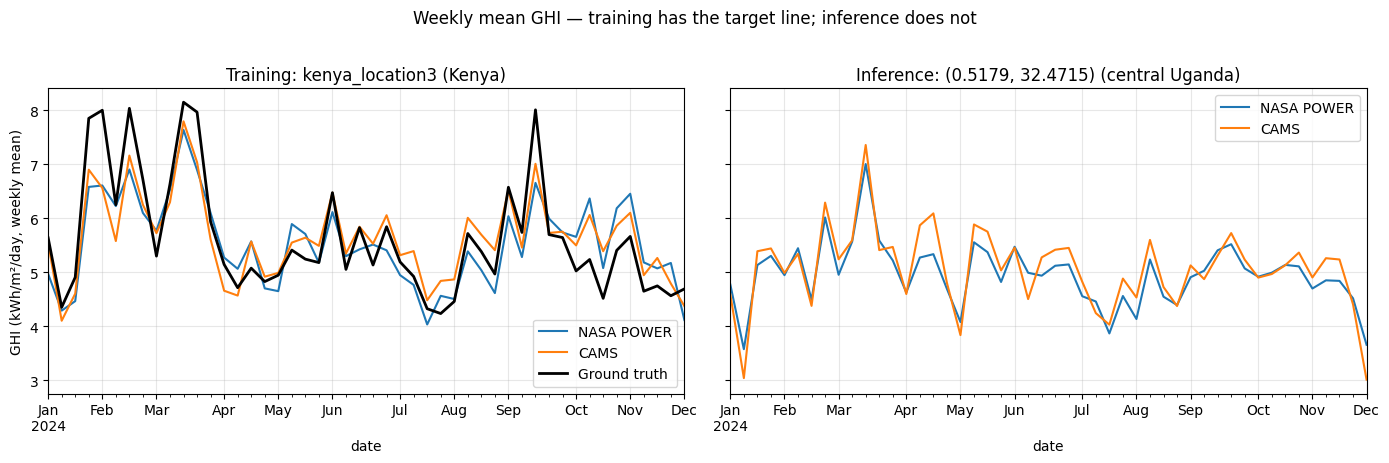

In [35]:
# Two-column GHI plot — training (with ground truth) vs inference (no
# ground truth). Weekly-averaged so the seasonal pattern is visible
# under the daily noise.
import matplotlib.pyplot as plt

weekly_train_ghi = (
    timeseries[
        ["y_ghi_kwh_m2_day", "sat_ghi_nasa_kwh_m2_day", "sat_ghi_cams_kwh_m2_day"]
    ]
    .resample("W")
    .mean()
)
weekly_inf_ghi = (
    inference_ts[["sat_ghi_nasa_kwh_m2_day", "sat_ghi_cams_kwh_m2_day"]]
    .resample("W")
    .mean()
)

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5), sharey=True)

# Left: training (kenya_location3, 2024) — model sees ground GHI as the target.
weekly_train_ghi["sat_ghi_nasa_kwh_m2_day"].plot(ax=axes[0], label="NASA POWER", color="C0")
weekly_train_ghi["sat_ghi_cams_kwh_m2_day"].plot(ax=axes[0], label="CAMS", color="C1")
weekly_train_ghi["y_ghi_kwh_m2_day"].plot(ax=axes[0], label="Ground truth", color="black", linewidth=2)
axes[0].set_title(f"Training: {example['location'].iloc[0]} (Kenya)")
axes[0].set_ylabel("GHI (kWh/m²/day, weekly mean)")
axes[0].grid(True, alpha=0.3)
axes[0].legend()

# Right: inference (Uganda grid point, 2024) — same features but no ground truth.
weekly_inf_ghi["sat_ghi_nasa_kwh_m2_day"].plot(ax=axes[1], label="NASA POWER", color="C0")
weekly_inf_ghi["sat_ghi_cams_kwh_m2_day"].plot(ax=axes[1], label="CAMS", color="C1")
axes[1].set_title(f"Inference: ({inference_lat}, {inference_lon}) (central Uganda)")
axes[1].grid(True, alpha=0.3)
axes[1].legend()

plt.suptitle("Weekly mean GHI — training has the target line; inference does not", y=1.02)
plt.tight_layout()
plt.show()

In [ ]:
# Two-column atmospheric features — same three NASA POWER variables at
# both locations. These go into the model alongside the satellite GHI
# estimate. Inference uses identical feature shape to training; only
# the ground-truth target is missing on the inference side.
weekly_train_vars = (
    timeseries[["nasa_aod_550", "nasa_precipitable_water", "nasa_cloud_amount"]]
    .resample("W")
    .mean()
)
weekly_inf_vars = (
    inference_ts[["nasa_aod_550", "nasa_precipitable_water", "nasa_cloud_amount"]]
    .resample("W")
    .mean()
)

fig, axes = plt.subplots(3, 2, figsize=(14, 9), sharex=True, sharey="row")

# Left column: training location.
weekly_train_vars["aod_550"].plot(ax=axes[0, 0], color="C2")
axes[0, 0].set_title(f"Training: {example['location'].iloc[0]}")
axes[0, 0].set_ylabel("AOD @ 550 nm")
weekly_train_vars["precipitable_water"].plot(ax=axes[1, 0], color="C3")
axes[1, 0].set_ylabel("Precipitable water (cm)")
weekly_train_vars["cloud_amount"].plot(ax=axes[2, 0], color="C4")
axes[2, 0].set_ylabel("Cloud amount (%)")
axes[2, 0].set_xlabel("Week")

# Right column: inference location.
weekly_inf_vars["aod_550"].plot(ax=axes[0, 1], color="C2")
axes[0, 1].set_title(f"Inference: ({inference_lat}, {inference_lon})")
weekly_inf_vars["precipitable_water"].plot(ax=axes[1, 1], color="C3")
weekly_inf_vars["cloud_amount"].plot(ax=axes[2, 1], color="C4")
axes[2, 1].set_xlabel("Week")

for ax in axes.flat:
    ax.grid(True, alpha=0.3)

plt.suptitle("NASA POWER atmospheric features — weekly mean", y=1.00)
plt.tight_layout()
plt.show()

## 3. Extending the warehouse

Whenever you want to train on a new station, score a new region, or pull a new variable, you ingest first. There are exactly three patterns, distinguished by what drives the location list:

| Pattern | Plan type | Use when |
|---|---|---|
| 1 | `NamedLocationsPlan` | You have specific points in mind — typically the 28 ground stations whose history you want covered for training. |
| 2 | `GridPlan` | You want uniform geographic coverage of a region — typically Uganda, or eventually all of sub-Saharan Africa, for the inference cache. |
| 3 | `GroundFilePlan` | A new ground-truth dataset has arrived from a station owner, partner, or publication. |

All three share the same lifecycle: **fetch → validate → server-side MERGE**. They differ only in how they resolve the location list and which fetcher they call. Two non-negotiable properties hold across every pattern:

- **Idempotency** — the coverage check pre-queries BigQuery for existing keys (date, geohash5, variable, source) and skips API calls for slices already loaded. Re-running a job is cheap. Ctrl+C mid-run is safe.
- **Migrations vs notebook cells** — the demo cells below run with `RUN_INGEST=False` by default and exist as reference. Real multi-station ingest belongs in `warehouse/migrations/*.py` (idempotent, dated, versioned in git). Don't flip `RUN_INGEST=True` and rerun the whole notebook; write a migration. See [`docs/architecture.md`](../docs/architecture.md) for the full operational guide.

### Pattern 1 — Named-location satellite ingest

Fetch a satellite source for a discrete set of locations — typically the ground stations whose history we want covered for training. Below: a plan for **Uganda 2025 + Kenya 2024** at ground-station coordinates. The job's coverage check skips slices already cached, so re-running is cheap.

In [37]:
# Pull station coordinates from the warehouse rather than hardcoding them.
stations = bq.query(f"""
SELECT location, ROUND(AVG(lat), 6) AS lat, ROUND(AVG(lon), 6) AS lon
FROM `{tables.ground_measurements}`
WHERE STARTS_WITH(location, 'kenya_') OR location IN ('kampala','lira','tororo','soroti','wadelai')
GROUP BY location
ORDER BY location
""")
stations

,location,lat,lon
0,kampala,0.333542,32.568630
1,kenya_location10,-1.451111,36.975687
2,kenya_location11,-1.494448,37.057094
3,kenya_location12,-0.224000,35.880000
4,kenya_location13,-1.491302,37.052862
5,kenya_location14,-1.451315,36.973008
6,kenya_location2,0.610000,36.800000
7,kenya_location3,-0.469974,35.181874
8,kenya_location4,-1.232761,36.878509
9,kenya_location5,-0.220000,35.860000


In [38]:
uganda_locations = tuple(
    LocationSpec(name=row.location, lat=float(row.lat), lon=float(row.lon))
    for row in stations.itertuples(index=False)
    if row.location in {"kampala", "lira", "tororo", "soroti", "wadelai"}
)
kenya_locations = tuple(
    LocationSpec(name=row.location, lat=float(row.lat), lon=float(row.lon))
    for row in stations.itertuples(index=False)
    if row.location.startswith("kenya_")
)

uganda_2025 = DateRange(start=date(2025, 1, 1), end=date(2025, 1, 31))
kenya_2024  = DateRange(start=date(2024, 1, 1), end=date(2024, 1, 31))

# Fetch the full set of NASA POWER variables this project tracks.
nasa_vars = VariableCatalog.for_source(Source.NASA_POWER)
cams_vars = VariableCatalog.for_source(Source.CAMS)

uganda_nasa_plan = NamedLocationsPlan(
    source=Source.NASA_POWER,
    date_range=uganda_2025,
    locations=uganda_locations,
    variables=nasa_vars,
)
kenya_nasa_plan = NamedLocationsPlan(
    source=Source.NASA_POWER,
    date_range=kenya_2024,
    locations=kenya_locations,
    variables=nasa_vars,
)
uganda_cams_plan = NamedLocationsPlan(
    source=Source.CAMS,
    date_range=uganda_2025,
    locations=uganda_locations,
    variables=cams_vars,
)
kenya_cams_plan = NamedLocationsPlan(
    source=Source.CAMS,
    date_range=kenya_2024,
    locations=kenya_locations,
    variables=cams_vars,
)

for plan in (uganda_nasa_plan, kenya_nasa_plan, uganda_cams_plan, kenya_cams_plan):
    print(plan.describe())

NamedLocations[source=NASA, locations=5, vars=32, dates=2025-01-01..2025-01-31]
NamedLocations[source=NASA, locations=13, vars=32, dates=2024-01-01..2024-01-31]
NamedLocations[source=CAMS, locations=5, vars=9, dates=2025-01-01..2025-01-31]
NamedLocations[source=CAMS, locations=13, vars=9, dates=2024-01-01..2024-01-31]


In [39]:
if RUN_INGEST:
    nasa_job = NasaPowerSatelliteJob(bq=bq, refs=tables)
    for plan in (uganda_nasa_plan, kenya_nasa_plan):
        result = nasa_job.run(plan)
        print(result.summary())
else:
    print("RUN_INGEST=False — skipping NASA POWER named-location runs.")
    print("Each plan above describes one job invocation; flip RUN_INGEST to execute.")

RUN_INGEST=False — skipping NASA POWER named-location runs.
Each plan above describes one job invocation; flip RUN_INGEST to execute.


In [40]:
# CAMS requires a registered email. Set CAMS_EMAIL in your environment
# (or .env) before running this cell.
if RUN_INGEST and os.getenv("CAMS_EMAIL"):
    cams_job = CamsSatelliteJob(bq=bq, refs=tables)
    for plan in (uganda_cams_plan, kenya_cams_plan):
        result = cams_job.run(plan)
        print(result.summary())
elif RUN_INGEST:
    print("RUN_INGEST=True but CAMS_EMAIL is not set — skipping CAMS runs.")
    print("Register an email at https://www.soda-pro.com/ and put it in .env as CAMS_EMAIL.")
else:
    print("RUN_INGEST=False — skipping CAMS named-location runs.")

RUN_INGEST=False — skipping CAMS named-location runs.


### Pattern 2 — Grid satellite ingest

The portal needs a satellite GHI estimate for any (lat, lon) in the region a user might query. Pre-cache them with a `GridPlan` over a bounding box at the source's native resolution, so the portal can serve cached estimates directly. Below: a tiny demo grid over a 0.5° × 0.5° patch of central Uganda at CAMS native 0.05° (121 grid points). Real region-wide grids run as separate, deliberate batches via migrations.

In [41]:
uganda_demo_bbox = BoundingBox(
    min_lat=0.10, max_lat=0.60,
    min_lon=32.30, max_lon=32.80,
)
demo_grid = GridSpec(bbox=uganda_demo_bbox, lat_step=0.05, lon_step=0.05)
demo_dates = DateRange(start=date(2025, 1, 1), end=date(2025, 1, 7))

demo_grid_plan = GridPlan(
    source=Source.CAMS,
    date_range=demo_dates,
    grid=demo_grid,
    variables=cams_vars,
)
print(demo_grid_plan.describe())
print(f"Grid points: {demo_grid.n_points}")

Grid[source=CAMS, points=121, vars=9, dates=2025-01-01..2025-01-07]
Grid points: 121


In [42]:
if RUN_INGEST and os.getenv("CAMS_EMAIL"):
    cams_job = CamsSatelliteJob(bq=bq, refs=tables)
    grid_result = cams_job.run(demo_grid_plan)
    print(grid_result.summary())
else:
    print("Grid ingest skipped (RUN_INGEST=False or CAMS_EMAIL not set).")
    print("This plan would call CAMS once per grid point that isn't already cached.")

Grid ingest skipped (RUN_INGEST=False or CAMS_EMAIL not set).
This plan would call CAMS once per grid point that isn't already cached.


### Pattern 3 — Ground-truth ingest

Future ground-truth additions arrive in heterogeneous formats from publications, ministries, and partner organisations. A `GroundSourceAdapter` parses one provider's CSV layout; downstream the curation function and MERGE loader are unchanged.

The CrossBoundary, Makerere, and Min.-of-Energy CSVs all share `(datetime, ghi, location, latitude, longitude)`, so a single `StandardCsvAdapter` handles all three. New layout = new adapter subclass.

The demo runs end-to-end against the real CrossBoundary Somalia file. Because every row is already in `ground_measurements_raw`, the idempotent coverage check causes the job to add zero rows — a real safety check that the pipeline doesn't double-write.

In [43]:
# Real on-disk file from the project's data directory.
somalia_csv = Path("../data/ground_measurements/CBE_Data/somalia.csv").resolve()
assert somalia_csv.exists(), f"Expected {somalia_csv} to exist."

adapter = StandardCsvAdapter(source_id="CBE")
raw_df = adapter.parse(somalia_csv)
print(f"Parsed {len(raw_df)} raw rows.")
raw_df.head()

Parsed 296 raw rows.


,datetime,ghi,location,latitude,longitude
0,2024-01-28,5550.759,somalia_location1,3.107191,43.637153
1,2024-02-01,5609.558,somalia_location1,3.107191,43.637153
2,2024-02-02,6353.845,somalia_location1,3.107191,43.637153
3,2024-02-03,5800.749,somalia_location1,3.107191,43.637153
4,2024-02-04,6444.199,somalia_location1,3.107191,43.637153


In [44]:
# Curation is a pure transformation — no I/O. Run it on the parsed raw rows
# to see what would land in `ground_measurements`.
curated_df = curate_ground(
    raw_df,
    CurationOptions(qc_level="auto", version="v1", geohash_precision=5),
)
print("Curated columns:", list(curated_df.columns))
curated_df.head()

Curated columns: ['date', 'month', 'location', 'lat', 'lon', 'geohash5', 'ghi_wh_m2_day', 'ghi_kwh_m2_day', 'qc_level', '_version', '_curated_at']


,date,month,location,lat,lon,geohash5,ghi_wh_m2_day,ghi_kwh_m2_day,qc_level,_version,_curated_at
0,2024-01-28,2024-01-01,somalia_location1,3.107191,43.637153,sbx18,5550.759,5.550759,auto,v1,2026-05-08 15:32:29.783339+00:00
1,2024-02-01,2024-02-01,somalia_location1,3.107191,43.637153,sbx18,5609.558,5.609558,auto,v1,2026-05-08 15:32:29.783339+00:00
2,2024-02-02,2024-02-01,somalia_location1,3.107191,43.637153,sbx18,6353.845,6.353845,auto,v1,2026-05-08 15:32:29.783339+00:00
3,2024-02-03,2024-02-01,somalia_location1,3.107191,43.637153,sbx18,5800.749,5.800749,auto,v1,2026-05-08 15:32:29.783339+00:00
4,2024-02-04,2024-02-01,somalia_location1,3.107191,43.637153,sbx18,6444.199,6.444199,auto,v1,2026-05-08 15:32:29.783339+00:00


In [45]:
# Run the full ingest path. Idempotent: if the data is already in the warehouse
# (which it is, for this CSV), the job adds zero rows and reports them all as
# already cached.
if RUN_INGEST:
    ground_plan = GroundFilePlan(
        source_id="CBE",
        file_path=somalia_csv,
        adapter_id=adapter.adapter_id,
    )
    ground_job = GroundIngestJob(bq=bq, adapter=adapter, refs=tables)
    ground_result = ground_job.run(ground_plan)
    print(ground_result.summary())
else:
    print("Ground ingest skipped (RUN_INGEST=False).")

Ground ingest skipped (RUN_INGEST=False).


### Extension recipes

| To add… | Do this |
|---|---|
| **A new ground station** | Drop the CSV at `data/ground_measurements/<provider>/<station>.csv`, pick or write a `GroundSourceAdapter`, run `GroundIngestJob` (Pattern 3), then re-run `2026-05-08_a6_ingest_28_ground_stations.py` — it pulls station metadata directly from `ground_measurements` and the coverage check skips already-ingested ones. |
| **A new ground-truth source with a different CSV layout** | Subclass `GroundSourceAdapter` and implement `parse(file_path) -> DataFrame` returning the canonical `(datetime, ghi, location, latitude, longitude)` schema. Everything downstream is unchanged. The adapter is the only thing that knows about the partner's column layout. |
| **A new satellite source** | Add a fetcher under `susse.api_clients/<source>/`, a `Source` enum value, `VariableSpec`s in `VariableCatalog`, a `TableSchema` + DDL + `CREATE TABLE` migration, a `BaseSatelliteJob` subclass, and an ingest migration. The MERRA-2 wire-up (Phase B, files prefixed `b1`–`b8`) is the worked template. |
| **A new region (inference coverage)** | Build a `GridPlan` with a `BoundingBox` for the region and run an existing satellite job (Pattern 2 below). Cost scales linearly with `n_grid_points × n_days × n_sources`; CAMS at native 0.05° is the expensive one. Densify pragmatically — start coarser, densify on demand. |
| **A new variable from an existing source** | Add a `VariableSpec` to the relevant `VariableCatalog` block, run the dim_variable migration to register it, then re-run the source's ingest. The job uses the catalog as its source-of-truth for what to fetch. |

The pattern demos that follow are read-only by default — they describe what *would* happen.

## What's next

This notebook is the first acceptance gate of a 7-step refactor track:

- **Notebook 02** picks up the audit + pair-availability cells above and assembles a versioned **TrainingDataset** snapshot — a parquet artifact tying a specific slice of the warehouse to a training run.
- **Notebooks 03–06** build the model side: preprocessor, model factory, trainer with native W&B integration, evaluation.
- **Notebook 07** closes the loop: a portal-facing inference API.

You're ready for notebook 02 when the pair-availability cell shows non-zero NASA + CAMS pairs at every station, the `dim_variable` catalog is populated, and you've run the MERRA-2 ingest if you want those features in the dataset.

If something here doesn't add up — a coverage warning, a confusing class name, a missing extension path — **edit this notebook**. It's the first thing the next person on this codebase will read.